# 📚 BÀI TẬP PHÂN CỤM SINH VIÊN
## Phân loại sinh viên thành 3 nhóm dựa trên điểm trung bình

**Mục đích:**
- Phân loại sinh viên: Giỏi / Khá / Trung bình–Yếu
- Chia học bổng
- Xác định các bạn cùng nhóm học lực tương đương

**Kỹ thuật sử dụng:** Phân cụm theo ngưỡng điểm TB + K-Means với Pipeline (Chương 38–39)

---

## 1️⃣ PHẦN 1: NHẬP THƯ VIỆN VÀ ĐỌC DỮ LIỆU

In [78]:
# Nhập các thư viện cần thiết
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
import warnings
warnings.filterwarnings('ignore')

# Cài đặt hiển thị
plt.style.use('default')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

print("✅ Các thư viện đã được nhập thành công!")

✅ Các thư viện đã được nhập thành công!


### Đọc và xem cấu trúc dữ liệu CSV

In [79]:
# ── Đọc file CSV ──────────────────────────────────────────────
file_path = 'bang_diem.csv'
df_raw = pd.read_csv(file_path, header=None)

print("📊 THÔNG TIN DỮ LIỆU GỐC:")
print(f"Kích thước: {df_raw.shape[0]} hàng × {df_raw.shape[1]} cột")

# Cấu trúc CSV:
#   Row 0  : tiêu đề file
#   Row 1  : MSSV (từ cột 3 trở đi)
#   Row 2  : Tên sinh viên (từ cột 3 trở đi)
#   Row 3  : header cột (STT / Mã môn / Tên môn / ...)
#   Row 4+ : điểm từng môn học

# Lấy thông tin sinh viên
mssv_row   = df_raw.iloc[1, 3:].values          # mảng MSSV
name_row   = df_raw.iloc[2, 3:].values          # mảng tên SV
subj_names = df_raw.iloc[4:, 2].values          # tên môn học
subj_codes = df_raw.iloc[4:, 1].values          # mã môn học

print(f"Số sinh viên: {len(mssv_row)}")
print(f"Số môn học  : {len(subj_names)}")
print(f"\n3 sinh viên đầu: {mssv_row[:3]}")
print(f"3 môn đầu      : {subj_names[:3]}")

📊 THÔNG TIN DỮ LIỆU GỐC:
Kích thước: 56 hàng × 74 cột
Số sinh viên: 71
Số môn học  : 52

3 sinh viên đầu: ['K225480106002' 'K225480106095' 'K225510201001']
3 môn đầu      : ['Kỹ thuật lập trình nâng cao' 'Trí tuệ nhân tạo và học máy' 'Xử lý ảnh']


---
## 2️⃣ PHẦN 2: TIỀN XỬ LÝ DỮ LIỆU

### Bước 1: Làm sạch và chuyển đổi dữ liệu

In [80]:
# ── Hàm làm sạch điểm ────────────────────────────────────────
def clean_score(val):
    """Chuyển đổi giá trị thô → float. Các ký tự '/', 'Nan', '-'... → NaN."""
    if pd.isna(val):
        return np.nan
    s = str(val).strip().replace(',', '.')   # dấu phẩy → dấu chấm
    try:
        return float(s)
    except ValueError:
        return np.nan  # '/', 'Nan', '-', 'nAn'... đều về NaN

# ── Xây dựng ma trận điểm (môn × sinh viên) ──────────────────
score_mat = df_raw.iloc[4:, 3:].copy()
score_mat.columns = range(len(mssv_row))

for col in score_mat.columns:
    score_mat[col] = score_mat[col].apply(clean_score)

# ── Tính điểm TB từng sinh viên (NaN không tính, 0 tính bình thường) ──
avg_scores   = score_mat.mean(axis=0, skipna=True)   # NaN bỏ qua
count_scores = score_mat.count(axis=0)               # số môn có điểm

result = pd.DataFrame({
    'MSSV'   : mssv_row,
    'Ho_Ten' : name_row,
    'Diem_TB': avg_scores.values,
    'So_mon' : count_scores.values,
})

# Bỏ sinh viên không có điểm nào hợp lệ
no_data = result[result['Diem_TB'].isna()]
if len(no_data) > 0:
    print(f"⚠️  {len(no_data)} sinh viên không có dữ liệu điểm (bỏ qua):")
    for _, r in no_data.iterrows():
        print(f"    {r['MSSV']} – {r['Ho_Ten']}")

result.dropna(subset=['Diem_TB'], inplace=True)
result.reset_index(drop=True, inplace=True)

print(f"\n✅ Tổng sinh viên có dữ liệu: {len(result)}")
print(f"\nThống kê điểm TB:")
print(result['Diem_TB'].describe().round(3))

⚠️  5 sinh viên không có dữ liệu điểm (bỏ qua):
    K225480106018 – Trần Quang Hiệp
    K225480106089 – Ma Quốc Hiếu
    K225480106023 – Nguyễn Văn Hoan
    K225480106094 – Nông Hồ Nhật
    K225480106069 – Lê Ngọc Tú

✅ Tổng sinh viên có dữ liệu: 66

Thống kê điểm TB:
count    66.000
mean      2.695
std       0.395
min       1.792
25%       2.415
50%       2.653
75%       2.994
max       3.545
Name: Diem_TB, dtype: float64


### Bước 2: Phân cụm theo ngưỡng điểm TB (cố định)

In [81]:
# ── Phân cụm theo ngưỡng ─────────────────────────────────────
# Cụm 1 – Giỏi   : ĐTB > 3.2
# Cụm 2 – Khá    : 2.5 ≤ ĐTB ≤ 3.2
# Cụm 3 – TB/Yếu : ĐTB < 2.5

def assign_cluster(score):
    if score > 3.2:
        return 1
    elif score >= 2.5:
        return 2
    else:
        return 3

def cluster_label(score):
    if score > 3.2:   return 'Cụm 1 (Giỏi)'
    elif score >= 2.5: return 'Cụm 2 (Khá)'
    else:              return 'Cụm 3 (TB/Yếu)'

result['Cum']       = result['Diem_TB'].apply(assign_cluster)
result['Cum_label'] = result['Diem_TB'].apply(cluster_label)

CLUSTER_COLORS = {
    'Cụm 1 (Giỏi)'   : '#2ECC71',
    'Cụm 2 (Khá)'    : '#3498DB',
    'Cụm 3 (TB/Yếu)' : '#E74C3C',
}
result['Color'] = result['Cum_label'].map(CLUSTER_COLORS)

# Tạo DataFrame con cho từng cụm
c1 = result[result['Cum'] == 1].copy()
c2 = result[result['Cum'] == 2].copy()
c3 = result[result['Cum'] == 3].copy()

print("📊 KẾT QUẢ PHÂN CỤM THEO NGƯỠNG ĐIỂM TB:")
print(f"  Cụm 1 – Giỏi   (>3.2)     : {len(c1):3d} SV  ({len(c1)/len(result)*100:.1f}%)")
print(f"  Cụm 2 – Khá    (2.5–3.2)  : {len(c2):3d} SV  ({len(c2)/len(result)*100:.1f}%)")
print(f"  Cụm 3 – TB/Yếu (<2.5)     : {len(c3):3d} SV  ({len(c3)/len(result)*100:.1f}%)")
print(f"\n  ĐTB toàn lớp  : {result['Diem_TB'].mean():.3f}")
print(f"  ĐTB cao nhất  : {result['Diem_TB'].max():.3f}")
print(f"  ĐTB thấp nhất : {result['Diem_TB'].min():.3f}")

📊 KẾT QUẢ PHÂN CỤM THEO NGƯỠNG ĐIỂM TB:
  Cụm 1 – Giỏi   (>3.2)     :   8 SV  (12.1%)
  Cụm 2 – Khá    (2.5–3.2)  :  36 SV  (54.5%)
  Cụm 3 – TB/Yếu (<2.5)     :  22 SV  (33.3%)

  ĐTB toàn lớp  : 2.695
  ĐTB cao nhất  : 3.545
  ĐTB thấp nhất : 1.792


### Bước 3: Thống kê mô tả dữ liệu

In [82]:
# ── Thống kê mô tả theo cụm ──────────────────────────────────
print("📈 THỐNG KÊ MÔ TẢ THEO CỤM:")
print("=" * 60)
for cum, df_c, col in [
    ('Cụm 1 – Giỏi',    c1, '\033[92m'),
    ('Cụm 2 – Khá',     c2, '\033[94m'),
    ('Cụm 3 – TB/Yếu',  c3, '\033[91m'),
]:
    print(f"\n🔷 {cum}:")
    print(f"   Số SV : {len(df_c)}")
    print(f"   ĐTB   : {df_c['Diem_TB'].mean():.3f}  "
          f"(min={df_c['Diem_TB'].min():.3f}, max={df_c['Diem_TB'].max():.3f})")
    print(f"   Std   : {df_c['Diem_TB'].std():.3f}")
    print(f"   Số môn TB: {df_c['So_mon'].mean():.1f}")

📈 THỐNG KÊ MÔ TẢ THEO CỤM:

🔷 Cụm 1 – Giỏi:
   Số SV : 8
   ĐTB   : 3.328  (min=3.209, max=3.545)
   Std   : 0.116
   Số môn TB: 50.6

🔷 Cụm 2 – Khá:
   Số SV : 36
   ĐTB   : 2.815  (min=2.500, max=3.185)
   Std   : 0.217
   Số môn TB: 50.6

🔷 Cụm 3 – TB/Yếu:
   Số SV : 22
   ĐTB   : 2.268  (min=1.792, max=2.483)
   Std   : 0.176
   Số môn TB: 47.5


---
## 3️⃣ PHẦN 3: XÂY DỰNG PIPELINE VÀ PHÂN CỤM K-MEANS

> Pipeline K-Means được giữ nguyên để so sánh với phân cụm theo ngưỡng.

### Bước 1: Chuẩn bị dữ liệu cho K-Means

In [83]:
# ── Xây dựng DataFrame sinh viên × môn học ───────────────────
# (cần cho K-Means và PCA)
score_mat_T = score_mat.T.copy()
score_mat_T.index = [f"{m} | {n}" for m, n in zip(range(len(mssv_row)), mssv_row)]
score_mat_T.columns = [f"{c}_{n}" for c, n in zip(subj_codes, subj_names)]

# Gán index đúng cho result
df_students = score_mat_T.iloc[
    [i for i in range(len(mssv_row)) if mssv_row[i] in result['MSSV'].values]
].copy()

# Chuyển tất cả sang numeric
for col in df_students.columns:
    df_students[col] = pd.to_numeric(df_students[col], errors='coerce')

# Loại cột NaN > 50%
cols_drop = df_students.columns[df_students.isnull().mean() > 0.5]
df_clean = df_students.drop(columns=cols_drop)
print(f"Loại {len(cols_drop)} môn có NaN > 50%, còn lại {df_clean.shape[1]} môn")

# Impute bằng mean
imputer = SimpleImputer(strategy='mean')
df_imputed = pd.DataFrame(
    imputer.fit_transform(df_clean),
    columns=df_clean.columns,
    index=df_clean.index
)
print(f"✅ Dữ liệu sau impute: {df_imputed.shape}")

Loại 1 môn có NaN > 50%, còn lại 51 môn
✅ Dữ liệu sau impute: (66, 51)


### Bước 2: Tìm k tối ưu – Elbow Method

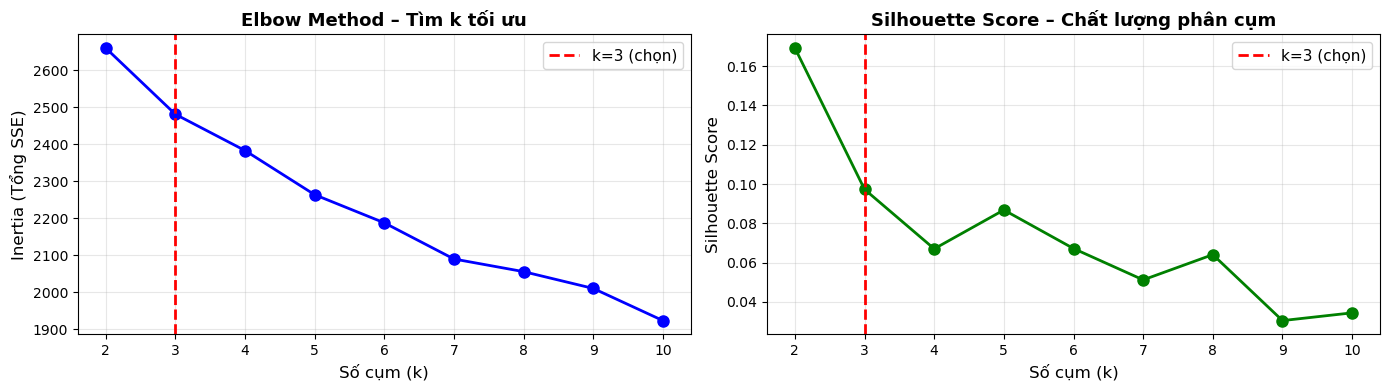

📊 Elbow & Silhouette:
  k=2   | Inertia=2660.43    | Silhouette=0.1693
  k=3   | Inertia=2481.27    | Silhouette=0.0973 ← Chọn
  k=4   | Inertia=2383.16    | Silhouette=0.0670
  k=5   | Inertia=2263.75    | Silhouette=0.0868
  k=6   | Inertia=2187.68    | Silhouette=0.0672
  k=7   | Inertia=2089.88    | Silhouette=0.0512
  k=8   | Inertia=2055.71    | Silhouette=0.0641
  k=9   | Inertia=2010.29    | Silhouette=0.0305
  k=10  | Inertia=1923.36    | Silhouette=0.0344


In [84]:
inertias = []
silhouette_scores_k = []
K_range = range(2, 11)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_imputed)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)
    silhouette_scores_k.append(silhouette_score(X_scaled, km.labels_))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
axes[0].axvline(x=3, color='red', linestyle='--', linewidth=2, label='k=3 (chọn)')
axes[0].set_xlabel('Số cụm (k)', fontsize=12)
axes[0].set_ylabel('Inertia (Tổng SSE)', fontsize=12)
axes[0].set_title('Elbow Method – Tìm k tối ưu', fontsize=13, fontweight='bold')
axes[0].grid(True, alpha=0.3)
axes[0].legend(fontsize=11)

axes[1].plot(K_range, silhouette_scores_k, 'go-', linewidth=2, markersize=8)
axes[1].axvline(x=3, color='red', linestyle='--', linewidth=2, label='k=3 (chọn)')
axes[1].set_xlabel('Số cụm (k)', fontsize=12)
axes[1].set_ylabel('Silhouette Score', fontsize=12)
axes[1].set_title('Silhouette Score – Chất lượng phân cụm', fontsize=13, fontweight='bold')
axes[1].grid(True, alpha=0.3)
axes[1].legend(fontsize=11)

plt.tight_layout()
plt.savefig('elbow_silhouette.png', dpi=300, bbox_inches='tight')
plt.show()

print("📊 Elbow & Silhouette:")
for k, inertia, sil in zip(K_range, inertias, silhouette_scores_k):
    marker = " ← Chọn" if k == 3 else ""
    print(f"  k={k:<3} | Inertia={inertia:<10.2f} | Silhouette={sil:.4f}{marker}")

### Bước 3: Tạo Pipeline và huấn luyện mô hình

In [85]:
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('kmeans', KMeans(n_clusters=3, random_state=42, n_init=10))
])

print("🚀 Đang huấn luyện mô hình k-Means...")
pipeline.fit(df_imputed)
print("✅ Hoàn thành!")

clusters = pipeline.predict(df_imputed)
df_imputed['Cụm'] = clusters
kmeans_model   = pipeline.named_steps['kmeans']
centroids_scaled = kmeans_model.cluster_centers_

print("\n📊 KẾT QUẢ PHÂN CỤM K-MEANS:")
print(f"Tổng sinh viên: {len(clusters)}")
for cid in range(3):
    cnt = (clusters == cid).sum()
    print(f"  Cụm {cid}: {cnt} SV ({cnt/len(clusters)*100:.1f}%)")
print(f"Inertia        : {kmeans_model.inertia_:.2f}")
print(f"Silhouette Score: {silhouette_score(X_scaled, clusters):.4f}")

🚀 Đang huấn luyện mô hình k-Means...
✅ Hoàn thành!

📊 KẾT QUẢ PHÂN CỤM K-MEANS:
Tổng sinh viên: 66
  Cụm 0: 22 SV (33.3%)
  Cụm 1: 23 SV (34.8%)
  Cụm 2: 21 SV (31.8%)
Inertia        : 2481.27
Silhouette Score: 0.0973


### Bước 4: Phân tích đặc trưng từng cụm K-Means

In [86]:
print("🎯 PHÂN TÍCH CÁC CỤM K-MEANS:")
print("=" * 80)
for cid in range(3):
    cd = df_imputed[df_imputed['Cụm'] == cid].drop('Cụm', axis=1)
    overall = cd.mean().mean()
    print(f"\n🔷 CỤM K-MEANS {cid}:")
    print(f"  Số SV         : {len(cd)}")
    print(f"  ĐTB chung     : {overall:.2f}")
    print(f"  Min / Max     : {cd.values.min():.2f} / {cd.values.max():.2f}")
print("=" * 80)

🎯 PHÂN TÍCH CÁC CỤM K-MEANS:

🔷 CỤM K-MEANS 0:
  Số SV         : 22
  ĐTB chung     : 2.29
  Min / Max     : 0.00 / 4.00

🔷 CỤM K-MEANS 1:
  Số SV         : 23
  ĐTB chung     : 3.14
  Min / Max     : 0.00 / 8.50

🔷 CỤM K-MEANS 2:
  Số SV         : 21
  ĐTB chung     : 2.65
  Min / Max     : 1.00 / 4.00


---
## 4️⃣ PHẦN 4: BIỂU ĐỒ GỐC – TRỰC QUAN HÓA K-MEANS

### Biểu đồ 1: PCA 2D

PCA variance: PC1=28.46%, PC2=6.51%


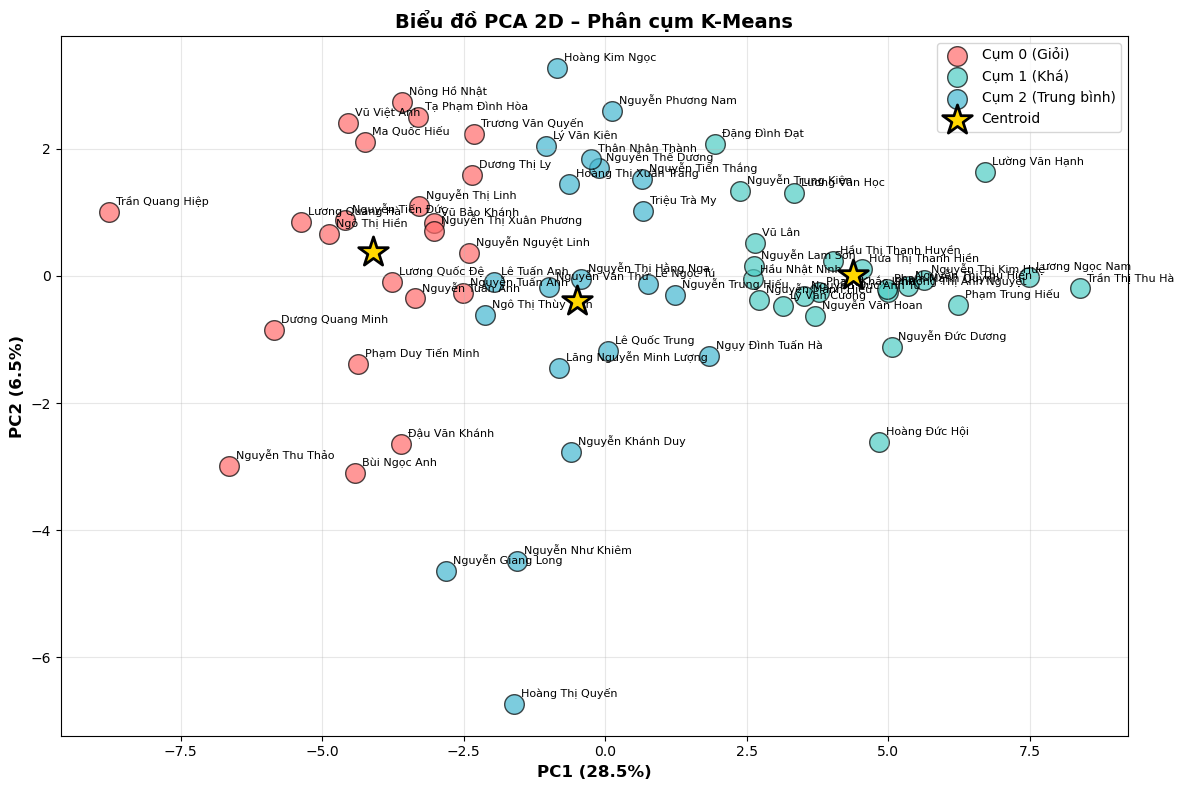

✅ Đã lưu pca_2d_clusters.png


In [87]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print(f"PCA variance: PC1={pca.explained_variance_ratio_[0]:.2%}, PC2={pca.explained_variance_ratio_[1]:.2%}")

fig, ax = plt.subplots(figsize=(12, 8))
colors_km  = ['#FF6B6B', '#4ECDC4', '#45B7D1']
labels_km  = ['Cụm 0 (Giỏi)', 'Cụm 1 (Khá)', 'Cụm 2 (Trung bình)']

for cid in range(3):
    mask = clusters == cid
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               c=colors_km[cid], label=labels_km[cid],
               s=200, alpha=0.7, edgecolors='black', linewidth=1)
# Thêm tên sinh viên
for i, name in enumerate(name_row[:len(X_pca)]):
    ax.annotate(
        name,
        (X_pca[i, 0], X_pca[i, 1]),
        textcoords="offset points",
        xytext=(5, 5),
        fontsize=8
    )

centroids_pca = pca.transform(centroids_scaled)
ax.scatter(centroids_pca[:, 0], centroids_pca[:, 1],
           c='gold', marker='*', s=500, edgecolors='black',
           linewidth=2, label='Centroid', zorder=5)

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})', fontsize=12, fontweight='bold')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})', fontsize=12, fontweight='bold')
ax.set_title('Biểu đồ PCA 2D – Phân cụm K-Means', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('pca_2d_clusters.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Đã lưu pca_2d_clusters.png")

### Biểu đồ 2: PCA 3D

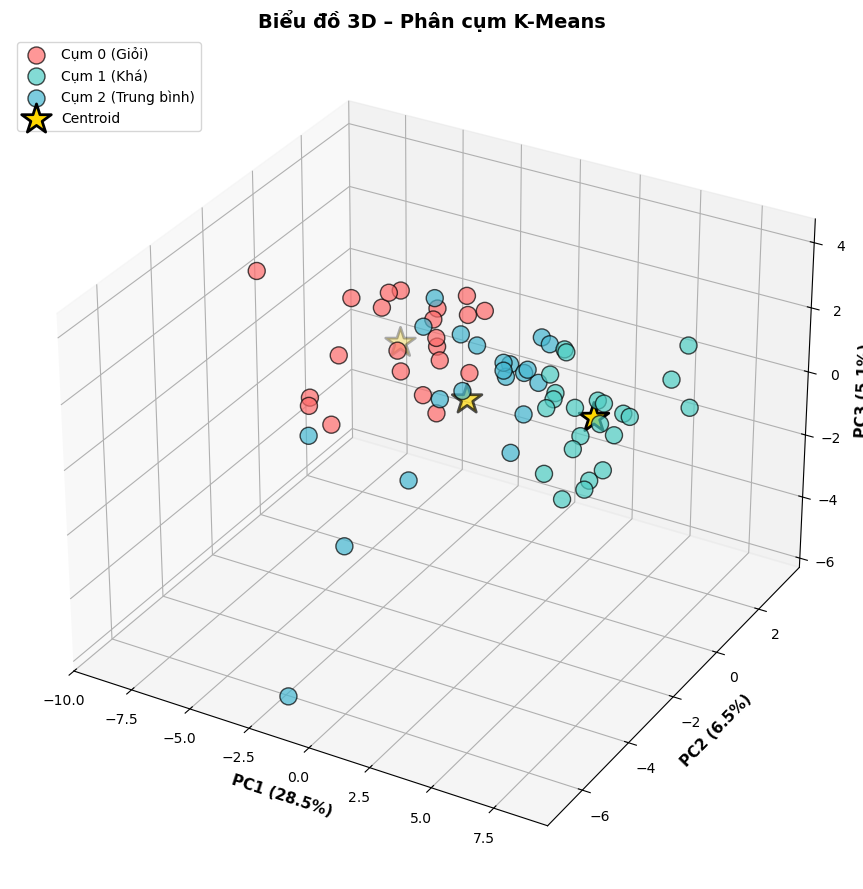

✅ Đã lưu pca_3d_clusters.png


In [88]:
from mpl_toolkits.mplot3d import Axes3D

pca_3d = PCA(n_components=3)
X_pca_3d = pca_3d.fit_transform(X_scaled)

fig = plt.figure(figsize=(12, 9))
ax  = fig.add_subplot(111, projection='3d')

for cid in range(3):
    mask = clusters == cid
    ax.scatter(X_pca_3d[mask, 0], X_pca_3d[mask, 1], X_pca_3d[mask, 2],
               c=colors_km[cid], label=labels_km[cid],
               s=150, alpha=0.7, edgecolors='black', linewidth=1)
# Thêm tên sinh viên
for i, name in enumerate(name_row[:len(X_pca)]):
    ax.annotate(
        name,
        (X_pca[i, 0], X_pca[i, 1]),
        textcoords="offset points",
        xytext=(5, 5),
        fontsize=8
    )
centroids_pca_3d = pca_3d.transform(centroids_scaled)
ax.scatter(centroids_pca_3d[:, 0], centroids_pca_3d[:, 1], centroids_pca_3d[:, 2],
           c='gold', marker='*', s=500, edgecolors='black',
           linewidth=2, label='Centroid', zorder=5)

ax.set_xlabel(f'PC1 ({pca_3d.explained_variance_ratio_[0]:.1%})', fontsize=11, fontweight='bold')
ax.set_ylabel(f'PC2 ({pca_3d.explained_variance_ratio_[1]:.1%})', fontsize=11, fontweight='bold')
ax.set_zlabel(f'PC3 ({pca_3d.explained_variance_ratio_[2]:.1%})', fontsize=11, fontweight='bold')
ax.set_title('Biểu đồ 3D – Phân cụm K-Means', fontsize=14, fontweight='bold')
ax.legend(fontsize=10, loc='upper left')
plt.tight_layout()
plt.savefig('pca_3d_clusters.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Đã lưu pca_3d_clusters.png")

### Biểu đồ 3: So sánh điểm TB các cụm K-Means

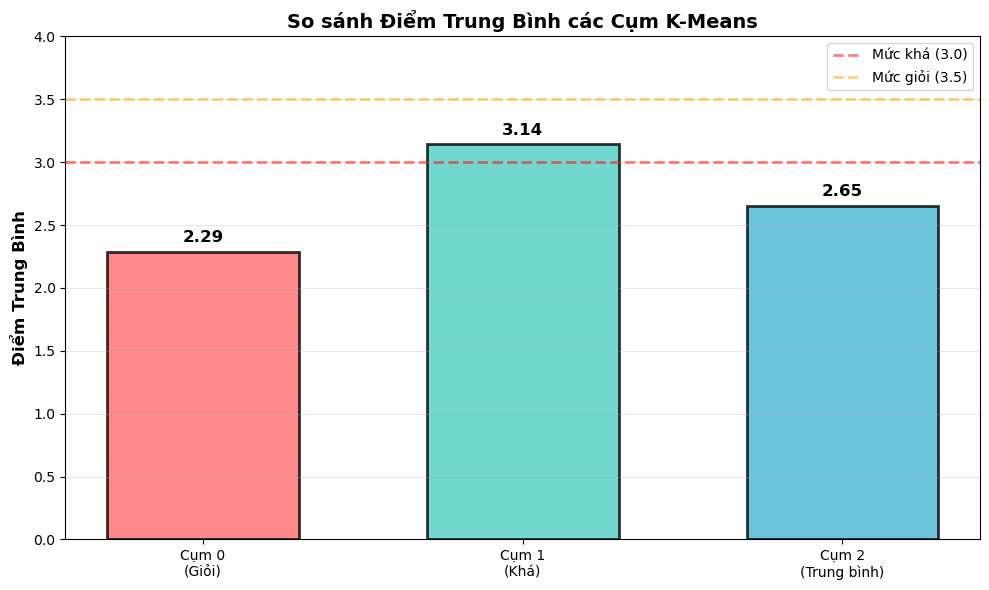

📊 ĐTB K-Means: ['Cụm 0=2.29', 'Cụm 1=3.14', 'Cụm 2=2.65']


In [89]:
cluster_means_km = []
for cid in range(3):
    cd = df_imputed[df_imputed['Cụm'] == cid].drop('Cụm', axis=1)
    cluster_means_km.append(cd.mean().mean())

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(['Cụm 0\n(Giỏi)', 'Cụm 1\n(Khá)', 'Cụm 2\n(Trung bình)'],
              cluster_means_km, color=colors_km,
              edgecolor='black', linewidth=2, width=0.6, alpha=0.8)
for bar, mean in zip(bars, cluster_means_km):
    ax.text(bar.get_x()+bar.get_width()/2., bar.get_height()+0.05,
            f'{mean:.2f}', ha='center', va='bottom', fontsize=12, fontweight='bold')

ax.axhline(y=3.0, color='red',    linestyle='--', linewidth=2, alpha=0.5, label='Mức khá (3.0)')
ax.axhline(y=3.5, color='orange', linestyle='--', linewidth=2, alpha=0.5, label='Mức giỏi (3.5)')
ax.set_ylabel('Điểm Trung Bình', fontsize=12, fontweight='bold')
ax.set_title('So sánh Điểm Trung Bình các Cụm K-Means', fontsize=14, fontweight='bold')
ax.set_ylim([0, 4.0]); ax.legend(fontsize=10); ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('cluster_means_comparison.png', dpi=300, bbox_inches='tight')
plt.show()
print("📊 ĐTB K-Means:", [f"Cụm {i}={m:.2f}" for i, m in enumerate(cluster_means_km)])

### Biểu đồ 4: Silhouette Plot

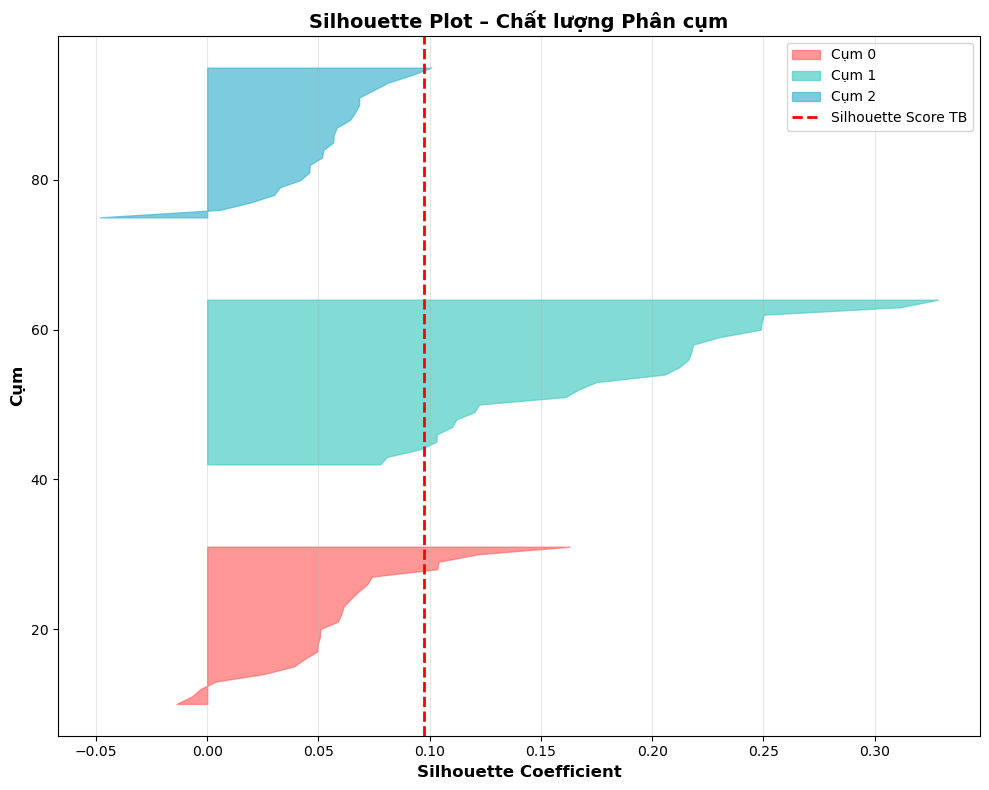

✅ Đã lưu silhouette_plot.png


In [90]:
silhouette_vals = silhouette_samples(X_scaled, clusters)

fig, ax = plt.subplots(figsize=(10, 8))
y_lower = 10
for i in range(3):
    sv = np.sort(silhouette_vals[clusters == i])
    y_upper = y_lower + len(sv)
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, sv,
                     facecolor=colors_km[i], edgecolor=colors_km[i],
                     alpha=0.7, label=f'Cụm {i}')
    y_lower = y_upper + 10

ax.axvline(x=silhouette_score(X_scaled, clusters), color='red',
           linestyle='--', linewidth=2, label='Silhouette Score TB')
ax.set_xlabel('Silhouette Coefficient', fontsize=12, fontweight='bold')
ax.set_ylabel('Cụm', fontsize=12, fontweight='bold')
ax.set_title('Silhouette Plot – Chất lượng Phân cụm', fontsize=14, fontweight='bold')
ax.legend(fontsize=10); ax.grid(True, axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('silhouette_plot.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Đã lưu silhouette_plot.png")

---
## 5️⃣ PHẦN 5: BIỂU ĐỒ MỚI – PHÂN CỤM THEO NGƯỠNG ĐIỂM TB

> Các biểu đồ dưới đây sử dụng kết quả phân cụm **theo ngưỡng cố định** (Cụm 1 >3.2 / Cụm 2 2.5–3.2 / Cụm 3 <2.5).

### Biểu đồ 5: Tổng quan – Pie + Cột + Histogram + Boxplot

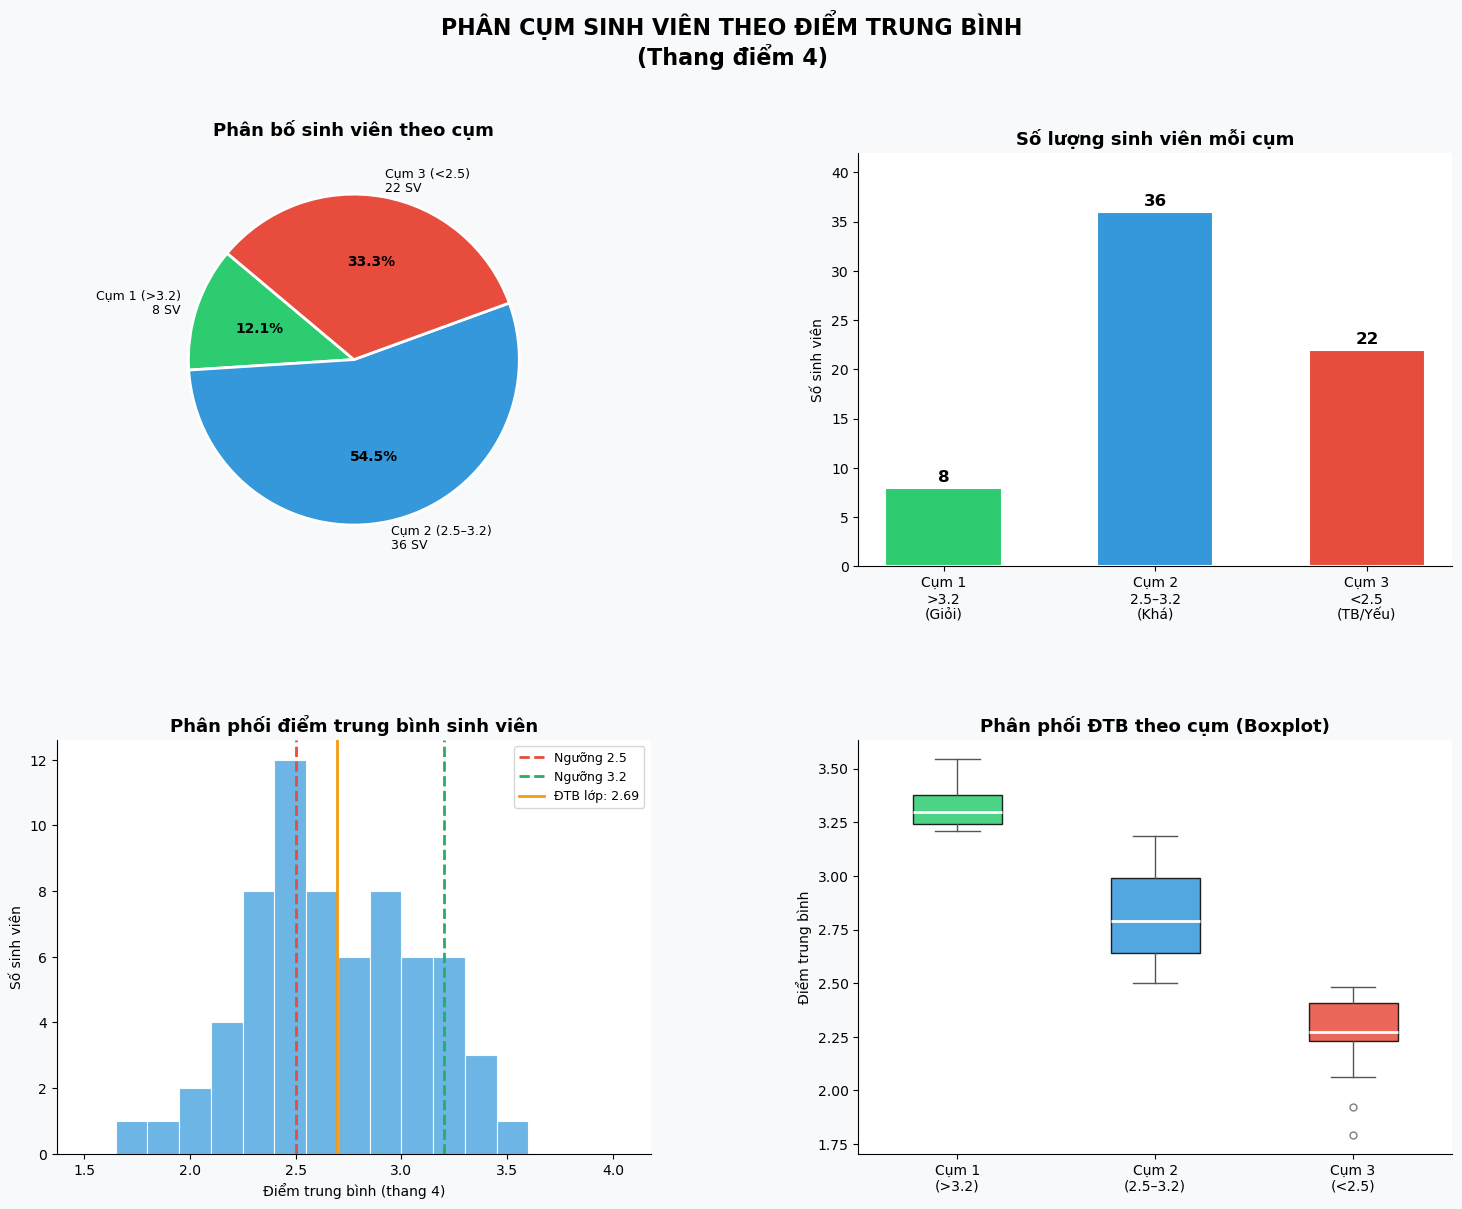

✅ Đã lưu chart5_overview_threshold.png


In [91]:
from matplotlib.gridspec import GridSpec

counts_cum = [len(c1), len(c2), len(c3)]
labels_pie = [f'Cụm 1 (>3.2)\n{counts_cum[0]} SV',
              f'Cụm 2 (2.5–3.2)\n{counts_cum[1]} SV',
              f'Cụm 3 (<2.5)\n{counts_cum[2]} SV']
colors_cum = ['#2ECC71', '#3498DB', '#E74C3C']

fig = plt.figure(figsize=(18, 13), facecolor='#F8F9FA')
gs  = GridSpec(2, 2, figure=fig, hspace=0.42, wspace=0.35)

# ── Pie ──────────────────────────────────────────────────────
ax_pie = fig.add_subplot(gs[0, 0])
wedges, texts, autotexts = ax_pie.pie(
    counts_cum, labels=labels_pie, colors=colors_cum,
    autopct='%1.1f%%', startangle=140,
    wedgeprops=dict(edgecolor='white', linewidth=2),
    textprops={'fontsize': 9})
for at in autotexts:
    at.set_fontsize(10); at.set_fontweight('bold')
ax_pie.set_title('Phân bố sinh viên theo cụm', fontsize=13, fontweight='bold', pad=12)

# ── Bar: số lượng ────────────────────────────────────────────
ax_bar = fig.add_subplot(gs[0, 1])
bars = ax_bar.bar(['Cụm 1\n>3.2\n(Giỏi)', 'Cụm 2\n2.5–3.2\n(Khá)',
                   'Cụm 3\n<2.5\n(TB/Yếu)'],
                  counts_cum, color=colors_cum,
                  edgecolor='white', linewidth=1.5, width=0.55)
for bar, cnt in zip(bars, counts_cum):
    ax_bar.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
                str(cnt), ha='center', va='bottom', fontsize=12, fontweight='bold')
ax_bar.set_title('Số lượng sinh viên mỗi cụm', fontsize=13, fontweight='bold')
ax_bar.set_ylabel('Số sinh viên', fontsize=10)
ax_bar.set_ylim(0, max(counts_cum)+6)
ax_bar.spines['top'].set_visible(False); ax_bar.spines['right'].set_visible(False)

# ── Histogram ĐTB ────────────────────────────────────────────
ax_hist = fig.add_subplot(gs[1, 0])
bins = np.arange(1.5, 4.1, 0.15)
ax_hist.hist(result['Diem_TB'], bins=bins, color='#5DADE2',
             edgecolor='white', linewidth=0.8, alpha=0.9)
ax_hist.axvline(2.5, color='#E74C3C', linestyle='--', linewidth=2, label='Ngưỡng 2.5')
ax_hist.axvline(3.2, color='#27AE60', linestyle='--', linewidth=2, label='Ngưỡng 3.2')
ax_hist.axvline(result['Diem_TB'].mean(), color='#F39C12', linestyle='-', linewidth=2,
                label=f'ĐTB lớp: {result["Diem_TB"].mean():.2f}')
ax_hist.set_title('Phân phối điểm trung bình sinh viên', fontsize=13, fontweight='bold')
ax_hist.set_xlabel('Điểm trung bình (thang 4)', fontsize=10)
ax_hist.set_ylabel('Số sinh viên', fontsize=10)
ax_hist.legend(fontsize=9)
ax_hist.spines['top'].set_visible(False); ax_hist.spines['right'].set_visible(False)

# ── Boxplot ──────────────────────────────────────────────────
ax_box = fig.add_subplot(gs[1, 1])
data_box = [c1['Diem_TB'].values, c2['Diem_TB'].values, c3['Diem_TB'].values]
bp = ax_box.boxplot(data_box, patch_artist=True, widths=0.45,
                    medianprops=dict(color='white', linewidth=2))
for patch, col in zip(bp['boxes'], colors_cum):
    patch.set_facecolor(col); patch.set_alpha(0.85)
for elem in ['whiskers', 'caps']:
    for item in bp[elem]: item.set_color('#555555')
for flier in bp['fliers']:
    flier.set(marker='o', markersize=5, alpha=0.5)
ax_box.set_xticklabels(['Cụm 1\n(>3.2)', 'Cụm 2\n(2.5–3.2)', 'Cụm 3\n(<2.5)'], fontsize=10)
ax_box.set_title('Phân phối ĐTB theo cụm (Boxplot)', fontsize=13, fontweight='bold')
ax_box.set_ylabel('Điểm trung bình', fontsize=10)
ax_box.spines['top'].set_visible(False); ax_box.spines['right'].set_visible(False)

fig.suptitle('PHÂN CỤM SINH VIÊN THEO ĐIỂM TRUNG BÌNH\n(Thang điểm 4)',
             fontsize=16, fontweight='bold', y=0.99)
plt.savefig('chart5_overview_threshold.png', dpi=150, bbox_inches='tight', facecolor='#F8F9FA')
plt.show()
print("✅ Đã lưu chart5_overview_threshold.png")

---
## 6️⃣ PHẦN 6: KẾT QUẢ PHÂN TÍCH & ỨNG DỤNG THỰC TẾ

### Danh sách sinh viên theo cụm

In [92]:
print("\n" + "="*100)
print("📋 DANH SÁCH SINH VIÊN THEO CỤM (NGƯỠNG ĐIỂM TB)")
print("="*100)

for label, df_c, emoji in [
    ('Cụm 1 – Giỏi (>3.2)',     c1, '🟢'),
    ('Cụm 2 – Khá (2.5–3.2)',   c2, '🔵'),
    ('Cụm 3 – TB/Yếu (<2.5)',   c3, '🔴'),
]:
    df_sorted = df_c.sort_values('Diem_TB', ascending=False)
    print(f"\n{emoji} {label}  ({len(df_c)} sinh viên)")
    print(f"  {'STT':<5} {'MSSV':<18} {'Họ tên':<30} {'ĐTB':<8} {'Số môn'}")
    print("  " + "-"*65)
    for idx, (_, r) in enumerate(df_sorted.iterrows(), 1):
        print(f"  {idx:<5} {r['MSSV']:<18} {r['Ho_Ten']:<30} {r['Diem_TB']:<8.2f} {r['So_mon']}")


📋 DANH SÁCH SINH VIÊN THEO CỤM (NGƯỠNG ĐIỂM TB)

🟢 Cụm 1 – Giỏi (>3.2)  (8 sinh viên)
  STT   MSSV               Họ tên                         ĐTB      Số môn
  -----------------------------------------------------------------
  1     K225480106009      Trần Thị Thu Hà                3.55     51
  2     K225480106053      Hoàng Kim Ngọc                 3.44     51
  3     K225480106019      Nguyễn Trung Hiếu              3.35     51
  4     K225480106013      Lường Văn Hạnh                 3.34     52
  5     K225480106058      Nguyễn Tiến Thắng              3.25     52
  6     K225480106015      Nguyễn Thị Thu Hiền            3.25     51
  7     K225480106093      Nguyễn Đức Dương               3.24     51
  8     K225480106056      Hoàng Thị Quyến                3.21     46

🔵 Cụm 2 – Khá (2.5–3.2)  (36 sinh viên)
  STT   MSSV               Họ tên                         ĐTB      Số môn
  -----------------------------------------------------------------
  1     K225480106099      Đ

### Nhận xét và Gợi ý

In [93]:
print("""
╔═══════════════════════════════════════════════════════════════════╗
║         🎓 NHẬN XÉT & GỢI Ý ỨNG DỤNG THỰC TẾ                    ║
╚═══════════════════════════════════════════════════════════════════╝

📌 PHÂN LOẠI SINH VIÊN (HỌC BỔNG):
   ✅ Cụm 1 – Giỏi (>3.2)     : Học bổng toàn phần
   ✅ Cụm 2 – Khá  (2.5–3.2)  : Học bổng một phần / hỗ trợ đặc biệt
   ⚠️  Cụm 3 – TB/Yếu (<2.5)  : Cần hỗ trợ / cảnh báo học lực

📌 CHIA NHÓM HỌC TẬP:
   • Ghép SV cùng cụm → cộng tác hiệu quả (trình độ tương đồng)
   • Ghép SV khác cụm → hỗ trợ lẫn nhau (peer-learning)

📌 HỖ TRỢ HỌC TẬP:
   • Cụm 3 cần tăng cường ôn tập các môn điểm thấp
   • Tổ chức lớp dạy kèm / buổi phụ đạo cho môn yếu chung

📌 DỰ BÁO KHẢ NĂNG TỐT NGHIỆP:
   • Cụm 1: Cao (GPA dự kiến ≥ 3.2)
   • Cụm 2: Bình thường (GPA ~ 2.5–3.2)
   • Cụm 3: Cần theo dõi sát
""")


╔═══════════════════════════════════════════════════════════════════╗
║         🎓 NHẬN XÉT & GỢI Ý ỨNG DỤNG THỰC TẾ                    ║
╚═══════════════════════════════════════════════════════════════════╝

📌 PHÂN LOẠI SINH VIÊN (HỌC BỔNG):
   ✅ Cụm 1 – Giỏi (>3.2)     : Học bổng toàn phần
   ✅ Cụm 2 – Khá  (2.5–3.2)  : Học bổng một phần / hỗ trợ đặc biệt
   ⚠️  Cụm 3 – TB/Yếu (<2.5)  : Cần hỗ trợ / cảnh báo học lực

📌 CHIA NHÓM HỌC TẬP:
   • Ghép SV cùng cụm → cộng tác hiệu quả (trình độ tương đồng)
   • Ghép SV khác cụm → hỗ trợ lẫn nhau (peer-learning)

📌 HỖ TRỢ HỌC TẬP:
   • Cụm 3 cần tăng cường ôn tập các môn điểm thấp
   • Tổ chức lớp dạy kèm / buổi phụ đạo cho môn yếu chung

📌 DỰ BÁO KHẢ NĂNG TỐT NGHIỆP:
   • Cụm 1: Cao (GPA dự kiến ≥ 3.2)
   • Cụm 2: Bình thường (GPA ~ 2.5–3.2)
   • Cụm 3: Cần theo dõi sát

